# Exercise 2:Random walks

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 2.1
**Compute the following 1D integral via Monte Carlo** 
$$I = \int_0^1 \frac{\pi}{2}\cos(\pi x/2) dx = 1$$ 
1. **sampling a uniform distribution in $[0,1]$**
2. **using importance sampling (i.e. sampling a non-uniform probability in $[0,1]$)**


To sample the integral with the standard mean method I just applied the data blocking method, which I implemented using the same struct as exercise 1,for 100 blocks with 10000 steps each. At each step I generated a value of $x$ between 0 and 1, computed $f(x)$, and incremented the sum. The final estimate is very precise, as we can see from the blue curve in the plot below, with error values ranging from $\sim$ 0,1% to $\sim$ 0.01% from the first to the last block. 
We can see this a sampling the integral $\int_0^1 f(x)p(x)dx$ with $p(x)$=1.
The idea of importance sampling is that we don't necessarily need to impose $p(x)=1$, but rather we could find a better probability distribution to sample from in order to get a better estimate of the integral. Usually, the best results are obtained by sampling probability distributions that are similar to the integrand function. 
I tried two possibilities:
- $\frac{3}{2}(1-x^2)$. I chose this because the parabolic shape resembles the cosine between 0 and 1, however I decided to sample it using the accept-reject method since inverting its cumulative could result in a very long expression.
- $d(x)=1-\frac{\pi}{2}(x-0.5)$ this is the normalized 1st order expansion of the integrand around the midpoint of the interval (0.5), and I sampled it with the inverse cumulative method. Even though it lacks the similarity in shape, we can see that it approximates the integrand better than the first case especially close to 0.

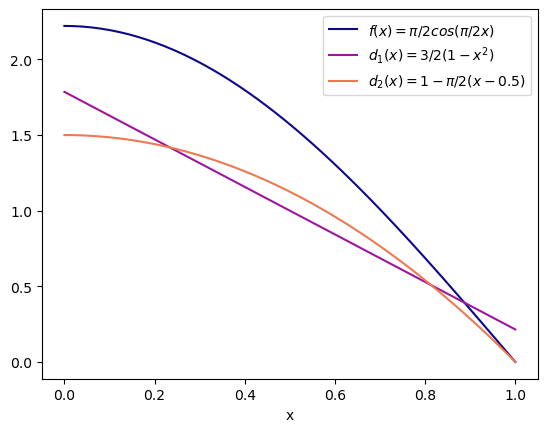

In [31]:
##visualization of the integrand and probability dstributions used for importance sampling
x=np.linspace(0,1)
y=np.pi *0.5*np.sqrt(2)*np.cos(np.pi*0.5*x)
colors =  plt.get_cmap("plasma", 4)
y2=3*0.5*(1-x**2)
y1= 1-np.pi*0.5*(x-0.5)

plt.plot(x,y,color=colors(0),label = r'$f(x)=\pi /2 cos(\pi/2 x)$')
plt.plot(x,y1,color=colors(1),label = r'$d_1(x)=3/2(1-x^2)$')
plt.plot(x,y2,color=colors(2),label = r'$d_2(x)=1-\pi /2(x-0.5)$')
plt.legend()
plt.xlabel('x')
plt.show()

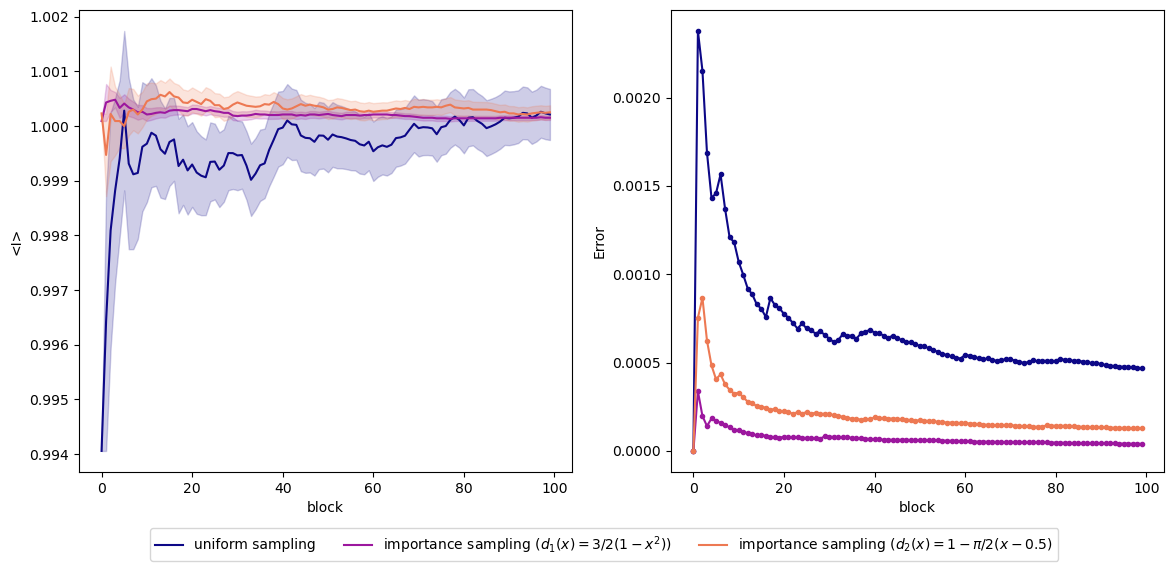

In [13]:
df = pd.read_csv("./OUTPUT/integral_uniform.csv",sep='\t')
df1= pd.read_csv("./OUTPUT/integral_IS_ar.csv",sep='\t')
df2= pd.read_csv("./OUTPUT/integral_IS_inv.csv",sep='\t')
fig,ax = plt.subplots(1,2,figsize=(14,6))


ax[0].plot(df['block'],df['block_ave'],color=colors(0),label='uniform sampling')
ax[0].fill_between(df['block'],df['block_ave']-df['err'],df['block_ave']+df['err'],alpha=0.2,color=colors(0))

ax[0].plot(df1['block'],df1['block_ave'],color=colors(1),label=r'importance sampling ($d_1(x)=3/2(1-x^2)$)')
ax[0].fill_between(df1['block'],df1['block_ave']-df1['err'],df1['block_ave']+df1['err'],alpha=0.2,color=colors(1),)

ax[0].plot(df2['block'],df2['block_ave'],color=colors(2),label=r'importance sampling ($d_2(x)=1-\pi /2(x-0.5)$')
ax[0].fill_between(df2['block'],df2['block_ave']-df2['err'],df2['block_ave']+df2['err'],color=colors(2),alpha=0.2)

ax[0].set_xlabel('block')
ax[0].set_ylabel('<I>')

ax[1].plot(df['block'],df['err'],color=colors(0),marker='.')
ax[1].plot(df1['block'],df1['err'],color=colors(1),marker='.')
ax[1].plot(df2['block'],df2['err'],color=colors(2),marker='.')
ax[1].set_xlabel('block')
ax[1].set_ylabel('Error')
fig.legend(
    loc='lower center',
    ncol=3,
    bbox_to_anchor=(0.5, -0.05)
)

As expected, using importance sampling significantly improves the integral estimation and reduces the errors significantly. The parabolic trial function is especially effective, since it performs the best in spite of the potential ineffectiveness of the accept-reject method.

## 2.2
**Repeat many times (e.g. say $10^4$) the simulation of a random walk in 3D always starting at the origin**
1. **on a cubic lattice with lattice constant $a=1$; at each discrete time the walker makes a forward or backward step of length equal to $a$ in one of the 3 principal directions of the lattice: $x$, $y$ or $z$**
2. **in the continuum; at each discrete time the walker makes a step of length equal to $a(=1)$ along a **random direction** obtained by sampling **uniformly** the solid angle: $\theta \in [0,\pi]$ and $\phi \in [0,2\pi]$**

**Show a picture of $\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}$ for both RWs</span>, with their statistical uncertainties, as function of the step $i\in [0,10^2]$.**

In order to simulate a generic random walk,I created a ```RandomWalk``` class that has as data members:
- a random generator rnd, which can be initialized with any seed: in this way each random walk object that is created is independent
- a position vector, whose dimension can be set when initializing the class according to the dimensionality of the problem
- total number of steps of the random walk

The class has functions that allow to set the position of the random walk, to retrieve information about it, and to evolve the position in different ways. In particular for this exercise I implemented a two types of step:
- a step on a lattice, meaning that the position can only vary on one of the 3 axes
- a uniform step, meaning that the position can vary in any direction as long as the step length is fixed

An example of the evolution if 10 random walks is shown in the figures below on the left.
Then the objective was to evaluate the average value of the travelled distance at every step. The way I built the random walk class allows me to create a vector of 100 random walks, and evolve them simultaneously: In this way I am able to evaluate the mean value of the travelled distance at each step with a standard blocking. Below are the results of the simulation of $10^4$ random walks divided in 100 blocks to evaluate the average distance at each of the 100 steps of their evolution. I also show the fit of the results with a model function $k\sqrt{N}$.
In both cases the block average follows the model very well, and we find a value of $k$ close to one. In the last plot I show the difference between the measured average and the model, and the difference between the two types of evolution. Even though they are very similar, especially further on in their evolution (closer to n=100), the lattice random walk exhibits a slightly more diffusive behaviour, which is coherent with the fact that it can only evolve on one of the 3 main exes.

In [28]:
from scipy.optimize import curve_fit
def plot_RW_fit(rw_type,f):
    df1 = pd.read_csv(f"./OUTPUT/RW_{rw_type}.csv", sep="\t")
    df2 = pd.read_csv(f"./OUTPUT/{rw_type}_distance.csv", sep="\t")

    fig = plt.figure(figsize=(16, 7))

    ax1 = fig.add_subplot(121, projection='3d')

    id_values = df1['walk_id'].unique()
    colors = plt.get_cmap("plasma", len(id_values))
    for i in id_values:
        ax1.plot(df1[df1['walk_id']==i]['x'], df1[df1['walk_id']==i]['y'],df1[df1['walk_id']==i]['z'],
                 label=f"Walk {i+1}", color=colors(i))
    
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    ax1.set_zlabel("Z")
    ax1.set_title("10 Random Walks")
    
    
    ax2 = fig.add_subplot(122)
    colors2 = plt.get_cmap("plasma", 4)
    x_vals = np.array(df2['step'])
    par,cov = curve_fit(f,x_vals,df2['block_ave'])
 
    fit = f(x_vals,par)
    ax2.plot(x_vals, f(x_vals,par), '--', label=f'k={par}',color=colors2(0))
    
    ax2.errorbar(df2['step'], df2['block_ave'], yerr=df2['err'],
                 fmt='o', markersize=4, label=r"$\sqrt{<r_N^2>}$",color=colors2(2))
    
    ax2.set_xlabel("Step")
    ax2.set_ylabel("Distance")
    ax2.set_title("Mean Distance")
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    return fit



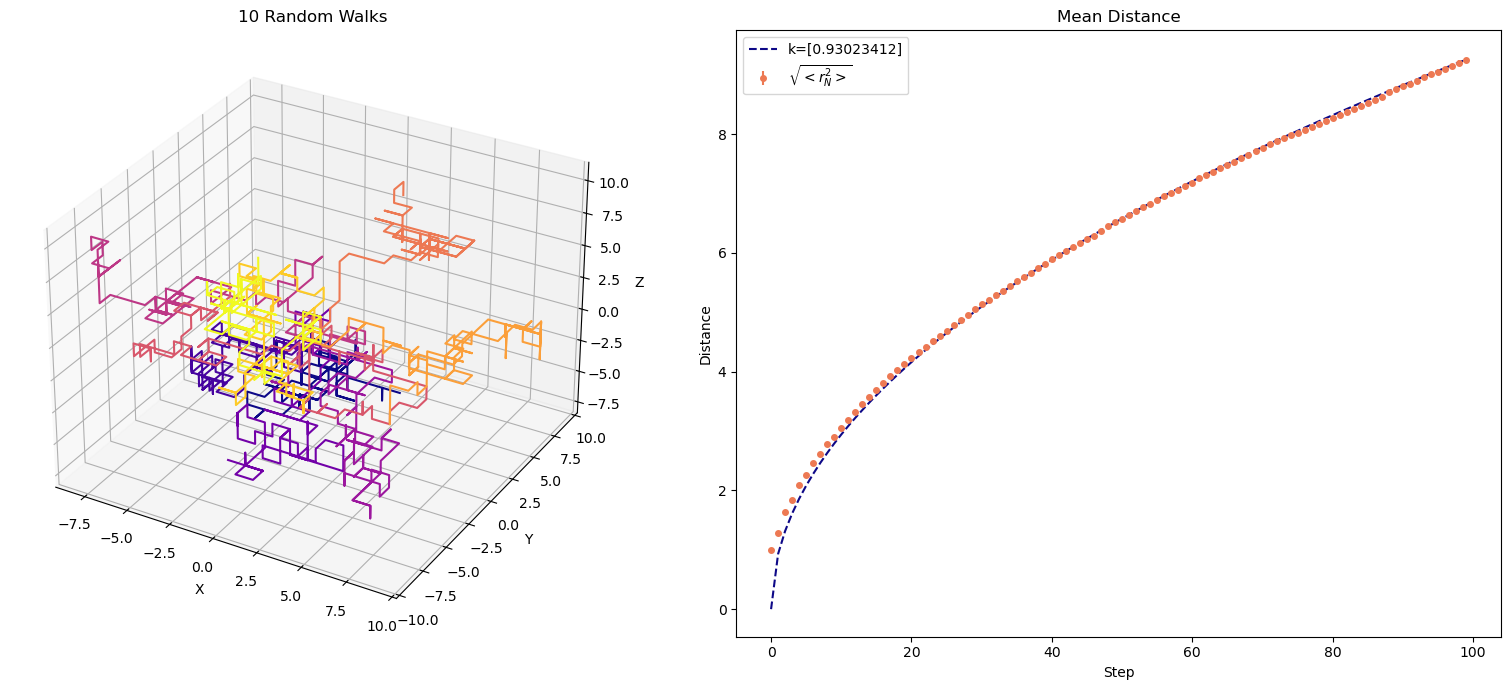

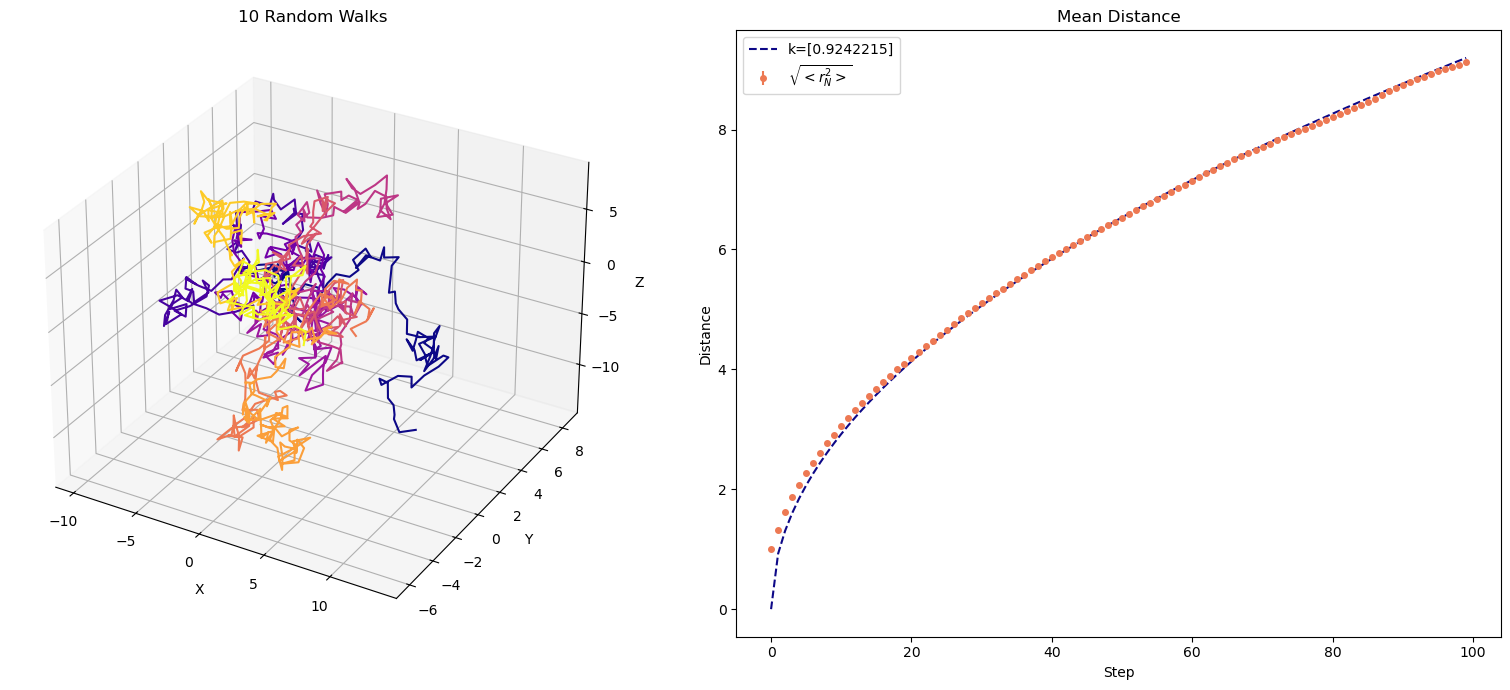

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def model(x,k):
    return k*np.sqrt(x)
fit1=plot_RW_fit('latt',model)
fit2=plot_RW_fit('cont',model)


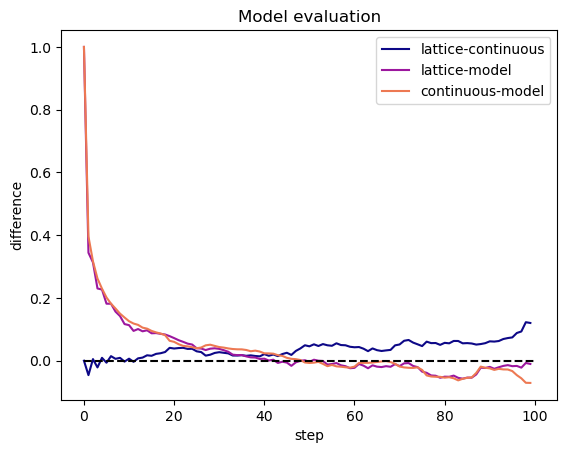

In [30]:
#residuals
dfl = pd.read_csv(f"./OUTPUT/latt_distance.csv", sep="\t")
dfc = pd.read_csv(f"./OUTPUT/cont_distance.csv", sep="\t")
    
x_vals = np.linspace(dfl['step'].min(), dfl['step'].max(), 100)
y_vals = np.sqrt(x_vals)
colors = plt.get_cmap("plasma", 4)
plt.plot(dfl['step'],dfl['block_ave']-dfc['block_ave'],label='lattice-continuous',color=colors(0))
plt.plot(dfl['step'],dfl['block_ave']-fit1,label='lattice-model',color=colors(1))
plt.plot(dfc['step'],dfc['block_ave']-fit2,label='continuous-model',color=colors(2))
plt.hlines(0,0,100,color='black',linestyle='dashed')
plt.legend()
plt.title('Model evaluation')
plt.xlabel('step')
plt.ylabel('difference')
plt.show()